# Notebook 03: Exploração e Validação da Camada Gold
**Projeto Integrador: Da Ingestão à Decisão (ENEM + ANEEL)**

Objetivo: auditar a Gold **antes** de confiar no modelo. Cada seção responde uma cobrança do enunciado:

| Seção | O que prova | Requisito |
| :--- | :--- | :--- |
| 1 | Granularidade declarada + chave primária sem duplicata + domínios válidos | Req. 3 |
| 2 | Coorte: quem entrou, quem saiu e se a exclusão enviesa a base | Req. 5 (coorte) |
| 3 | Label: balanceamento, sensibilidade ao limiar de 35% e persistência | Req. 5 (label) |
| 4 | Features: distribuição, sinal univariado e redundância | Req. 5 |
| 5 | Checklist anti-vazamento **com prova em código** | Req. 5 |
| 6 | Split temporal, baselines e métricas para classe desbalanceada | Req. 5 |
| 7 | Decisão: top-K, custo de errar e sensibilidade ao K | Req. 6 |

Este notebook **só lê** a Gold. Nenhuma limpeza acontece aqui (se precisar limpar, a Silver falhou).

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# Sobe pastas até achar a raiz do repo (a que tem src/), igual aos outros notebooks
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

GOLD_ML = ROOT / "data/gold/ml_ready/enem_aneel_ml_ready.parquet"
GOLD_AN = ROOT / "data/gold/analytics"
SILVER_JOINED = ROOT / "data/silver/joined/silver_joined.parquet"
SILVER_ANEEL = ROOT / "data/silver/aneel/aneel_silver.parquet"

# Constantes iguais às de train_predictor.py / evaluate.py (se mudar lá, mude aqui)
SEED = 42              # semente fixa em toda operação aleatória
K = 50                 # capacidade da decisão: 50 geradores
CUSTO_GERADOR = 15_000 # R$ por gerador (3 meses de locação + combustível)
LIMIAR = 0.35          # abstenção > 35% = município crítico
CHAVE = ["codigo_municipio", "ano"]
TARGET = "target_abstencao_critica"
FEATURES = ["fec_medio_jan_jul", "dec_horas_total_jan_jul", "dec_horas_medio_jan_jul",
            "fec_medio_reta_final", "dec_horas_total_reta_final",
            "dec_horas_pior_mes", "dec_variacao_ano"]
# Colunas que só existem depois da prova: nunca podem virar feature
FUTURO = {"taxa_abstencao", "total_abstencao", "total_inscritos", TARGET}

np.random.seed(SEED)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
print("raiz:", ROOT)
print(sorted(p.relative_to(ROOT).as_posix() for p in (ROOT / "data/gold").glob("**/*") if p.is_file()))

raiz: c:\Users\imbir\OneDrive\Documentos\Nova pasta\enem-aneel-pipeline
['data/gold/analytics/.gitkeep', 'data/gold/analytics/gold_exploracao_resumo.json', 'data/gold/ml_ready/.gitkeep', 'data/gold/ml_ready/enem_aneel_ml_ready.parquet']


In [2]:
for camada in ["bronze", "silver", "gold", "quarantine"]:
    arqs = [p.relative_to(ROOT).as_posix() for p in (ROOT / "data" / camada).glob("**/*") if p.is_file()]
    print(camada, "->", len(arqs), "arquivos")
    for a in arqs[:8]:
        print("   ", a)

bronze -> 9 arquivos
    data/bronze/aneel/.gitkeep
    data/bronze/aneel/aneel_conjuntos_municipios.parquet
    data/bronze/aneel/aneel_dec_fec_20261001.parquet
    data/bronze/enem/.gitkeep
    data/bronze/enem/enem_2020.parquet
    data/bronze/enem/enem_2021.parquet
    data/bronze/enem/enem_2022.parquet
    data/bronze/enem/enem_2023.parquet
silver -> 9 arquivos
    data/silver/aneel/.gitkeep
    data/silver/aneel/aneel_silver.parquet
    data/silver/enem/.gitkeep
    data/silver/enem/enem_silver.parquet
    data/silver/joined/.gitkeep
    data/silver/joined/metricas_join.json
    data/silver/joined/relatorio_join_enem_aneel.md
    data/silver/joined/relatorio_qualidade_silver.md
gold -> 4 arquivos
    data/gold/analytics/.gitkeep
    data/gold/analytics/gold_exploracao_resumo.json
    data/gold/ml_ready/.gitkeep
    data/gold/ml_ready/enem_aneel_ml_ready.parquet
quarantine -> 2 arquivos
    data/quarantine/aneel/.gitkeep
    data/quarantine/enem/.gitkeep


## 1. Contrato da tabela Gold
Granularidade declarada: **uma linha por município por ano de aplicação do ENEM**.
A chave primária `(codigo_municipio, ano)` precisa ser provada sem duplicata.

In [3]:
gold = pd.read_parquet(GOLD_ML)
print("shape:", gold.shape)
gold.head()

shape: (391, 16)


,codigo_municipio,NomMunicipio,ano,fec_medio_jan_jul,dec_horas_total_jan_jul,dec_horas_medio_jan_jul,meses_observados,fec_medio_reta_final,dec_horas_total_reta_final,dec_horas_pior_mes,dec_horas_mes1,dec_variacao_ano,total_inscritos,total_abstencao,taxa_abstencao,target_abstencao_critica
0,1500107,ABAETETUBA,2020,0.37,2.90,0.41,7,0.426667,1.40,0.86,0.0,0.86,8233,3985,0.4840,1
1,1500107,ABAETETUBA,2021,0.37,2.90,0.41,7,0.426667,1.40,0.86,0.0,0.86,5198,1778,0.3421,0
2,1500107,ABAETETUBA,2022,0.43,2.84,0.41,7,0.403333,1.61,0.82,0.0,0.82,5155,1650,0.3201,0
3,1500107,ABAETETUBA,2023,0.04,0.34,0.05,7,0.023333,0.23,0.14,0.0,0.14,6178,1978,0.3202,0
4,1500107,ABAETETUBA,2024,0.34,2.54,0.36,7,0.370000,1.32,0.61,0.0,0.61,6601,1711,0.2592,0


In [4]:
gold.dtypes

codigo_municipio               object
NomMunicipio                   object
ano                             int64
fec_medio_jan_jul             float64
dec_horas_total_jan_jul       float64
dec_horas_medio_jan_jul       float64
meses_observados                int64
fec_medio_reta_final          float64
dec_horas_total_reta_final    float64
dec_horas_pior_mes            float64
dec_horas_mes1                float64
dec_variacao_ano              float64
total_inscritos                 int64
total_abstencao                 int64
taxa_abstencao                float64
target_abstencao_critica        int64
dtype: object

In [5]:
# --- Chave primária: provar com código que não há duplicata
assert gold[CHAVE].notna().all().all(), "Nulo na chave (codigo_municipio, ano)"
n_dup = gold.duplicated(CHAVE).sum()
assert n_dup == 0, f"{n_dup} linhas duplicadas na chave {CHAVE}"
print("PK (codigo_municipio, ano): OK, 0 duplicatas")

# --- Granularidade: quantos municípios x anos, e se o painel é balanceado
anos = sorted(gold["ano"].unique().tolist())
print(f"{len(gold)} linhas = {gold['codigo_municipio'].nunique()} municípios x {len(anos)} anos {anos}")
print("\nQuantos anos cada município tem (painel balanceado = tudo igual):")
print(gold.groupby("codigo_municipio")["ano"].nunique().value_counts().sort_index())

PK (codigo_municipio, ano): OK, 0 duplicatas
391 linhas = 81 municípios x 5 anos [2020, 2021, 2022, 2023, 2024]

Quantos anos cada município tem (painel balanceado = tudo igual):
ano
1     2
2     2
5    77
Name: count, dtype: int64


In [6]:
# --- Colunas esperadas (as que o dicionário e o treino assumem)
esperadas = CHAVE + ["NomMunicipio", "meses_observados", "total_inscritos", "total_abstencao",
                     "taxa_abstencao", TARGET] + FEATURES
print("faltando na Gold:", [c for c in esperadas if c not in gold.columns])
print("extras na Gold  :", [c for c in gold.columns if c not in esperadas])

faltando na Gold: []
extras na Gold  : ['dec_horas_mes1']


In [7]:
# --- Domínios válidos (cada linha é uma regra do contrato; False = investigar a Silver)
contrato = {
    "taxa_abstencao em [0,1]": gold["taxa_abstencao"].between(0, 1).all(),
    "total_inscritos >= 1": (gold["total_inscritos"] >= 1).all(),
    "total_abstencao <= total_inscritos": (gold["total_abstencao"] <= gold["total_inscritos"]).all(),
    "meses_observados em [1,7]": gold["meses_observados"].between(1, 7).all(),
    "fec/dec sem valor negativo": (gold[[c for c in FEATURES if c != "dec_variacao_ano"]].dropna() >= 0).all().all(),
    "target só 0/1": set(gold[TARGET].unique()) <= {0, 1},
    f"target == (taxa_abstencao > {LIMIAR})": (gold[TARGET] == (gold["taxa_abstencao"] > LIMIAR).astype(int)).all(),
    "codigo_municipio com 7 dígitos": gold["codigo_municipio"].astype(str).str.fullmatch(r"\d{7}").all(),
}
pd.Series(contrato, name="passou?").to_frame()

,passou?
"taxa_abstencao em [0,1]",True
total_inscritos >= 1,True
total_abstencao <= total_inscritos,True
"meses_observados em [1,7]",True
fec/dec sem valor negativo,True
target só 0/1,True
target == (taxa_abstencao > 0.35),True
codigo_municipio com 7 dígitos,True


In [8]:
# --- Nulos por coluna. NaN em dec_variacao_ano / *_reta_final é esperado quando falta o mês 1 ou maio-julho
nulos = gold.isna().sum().to_frame("nulos")
nulos["%"] = (nulos["nulos"] / len(gold) * 100).round(1)
nulos[nulos["nulos"] > 0]

,nulos,%
dec_horas_mes1,7,1.8
dec_variacao_ano,7,1.8


## 2. Coorte
Regra: só entra município-ano com os **7 meses** (jan-jul) de energia observados. Com menos meses, as somas de horas
ficam subestimadas e o modelo aprenderia "pouco dado" como "pouca queda". O treino aplica o filtro
(`meses_observados == 7`); aqui medimos o custo dele.

In [9]:
gold["coorte"] = gold["meses_observados"] == 7
resumo = gold.groupby("ano").agg(
    municipios=("codigo_municipio", "size"),
    na_coorte=("coorte", "sum"),
    excluidos=("coorte", lambda s: (~s).sum()),
)
resumo["% excluido"] = (resumo["excluidos"] / resumo["municipios"] * 100).round(1)
resumo

,municipios,na_coorte,excluidos,% excluido
ano,,,,
2020,77,71,6,7.8
2021,77,71,6,7.8
2022,77,74,3,3.9
2023,79,77,2,2.5
2024,81,79,2,2.5


In [10]:
# A exclusão enviesa? Se os excluídos têm taxa de crítico bem diferente, a coorte muda a pergunta.
comp = gold.groupby("coorte").agg(n=(TARGET, "size"), taxa_positivos=(TARGET, "mean"),
                                  abstencao_media=("taxa_abstencao", "mean"),
                                  inscritos_medio=("total_inscritos", "mean")).round(3)
print(comp)

print("\nQuem são os excluídos (meses_observados < 7):")
excl = gold.loc[~gold["coorte"], CHAVE + ["NomMunicipio", "meses_observados", TARGET]]
print(excl["meses_observados"].value_counts().sort_index().to_string())
excl.sort_values(CHAVE).head(15)

          n  taxa_positivos  abstencao_media  inscritos_medio
coorte                                                       
False    19           0.684            0.426          905.105
True    372           0.540            0.387         3170.720

Quem são os excluídos (meses_observados < 7):
meses_observados
4     3
5     2
6    14


,codigo_municipio,ano,NomMunicipio,meses_observados,target_abstencao_critica
25,1500701,2020,ANAJÁS,4,1
26,1500701,2021,ANAJÁS,4,1
29,1500701,2024,ANAJÁS,4,1
130,1502939,2020,DOM ELISEU,6,1
131,1502939,2021,DOM ELISEU,6,0
140,1503044,2020,FLORESTA DO ARAGUAIA,6,1
141,1503044,2021,FLORESTA DO ARAGUAIA,6,1
150,1503200,2020,IGARAPÉ-AÇU,6,1
151,1503200,2021,IGARAPÉ-AÇU,6,1
154,1503200,2024,IGARAPÉ-AÇU,6,0


In [11]:
# Origem da exclusão: janela jan-jul incompleta já na Silver ANEEL (confere com o que a Gold mostra)
an = pd.read_parquet(SILVER_ANEEL)
jan_jul = an[an["mes"] <= 7].groupby(["codigo_municipio", "ano"])["mes"].nunique()
print("município-ano na Silver ANEEL com jan-jul incompleto:", int((jan_jul < 7).sum()))

# Se o pipeline gravar o log da coorte, mostramos também (arquivo opcional)
f_exc = GOLD_AN / "coorte_excluidos.parquet"
if f_exc.exists():
    exc = pd.read_parquet(f_exc)
    print(exc.groupby(["_motivo_exclusao", "ano"]).size())
else:
    print("coorte_excluidos.parquet não existe (silver_to_gold.py atual não grava; ver pendências).")

município-ano na Silver ANEEL com jan-jul incompleto: 34
coorte_excluidos.parquet não existe (silver_to_gold.py atual não grava; ver pendências).


In [12]:
# Daqui para frente, trabalhamos só com a coorte
df = gold[gold["coorte"]].drop(columns="coorte").copy()
print("coorte:", len(df), "de", len(gold), "município-ano")

coorte: 372 de 391 município-ano


## 3. O label (`target_abstencao_critica`)
Positivo = município com abstenção > 35% no ENEM do ano. Só se sabe depois da prova (posterior ao t0).

In [13]:
por_ano = df.groupby("ano").agg(n=(TARGET, "size"), positivos=(TARGET, "sum"),
                                taxa_positivos=(TARGET, "mean"),
                                abstencao_media=("taxa_abstencao", "mean"),
                                abstencao_mediana=("taxa_abstencao", "median")).round(3)
por_ano

,n,positivos,taxa_positivos,abstencao_media,abstencao_mediana
ano,,,,,
2020,71,71,1.000,0.553,0.547
2021,71,52,0.732,0.372,0.369
2022,74,39,0.527,0.364,0.352
2023,77,29,0.377,0.344,0.343
2024,79,10,0.127,0.313,0.310


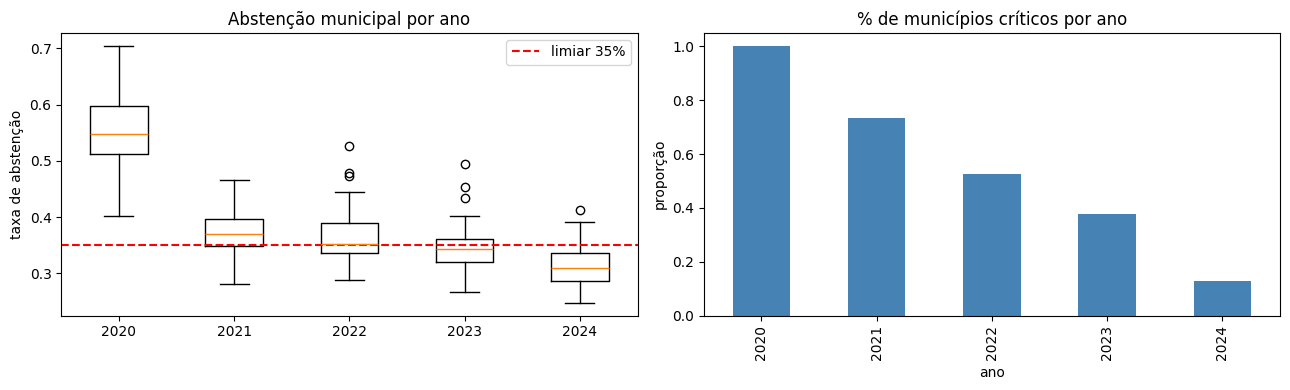

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
dados = [df.loc[df["ano"] == a, "taxa_abstencao"] for a in sorted(df["ano"].unique())]
ax[0].boxplot(dados, tick_labels=sorted(df["ano"].unique()))
ax[0].axhline(LIMIAR, color="red", ls="--", label=f"limiar {LIMIAR:.0%}")
ax[0].set_title("Abstenção municipal por ano"); ax[0].set_ylabel("taxa de abstenção"); ax[0].legend()
por_ano["taxa_positivos"].plot(kind="bar", ax=ax[1], color="steelblue")
ax[1].set_title("% de municípios críticos por ano"); ax[1].set_ylabel("proporção")
plt.tight_layout(); plt.show()

In [15]:
# Sensibilidade ao limiar: se a taxa de positivos muda muito entre 30% e 40%, o 35% é frágil
limiares = [0.25, 0.30, 0.35, 0.40, 0.45]
sens = pd.DataFrame({f">{l:.0%}": (df["taxa_abstencao"] > l).groupby(df["ano"]).mean() for l in limiares}).round(2)
sens

,>25%,>30%,>35%,>40%,>45%
ano,,,,,
2020,1.00,1.00,1.00,1.00,0.97
2021,1.00,0.97,0.73,0.24,0.03
2022,1.00,0.99,0.53,0.16,0.04
2023,1.00,0.94,0.38,0.06,0.03
2024,0.99,0.57,0.13,0.01,0.00


In [16]:
# Municípios pequenos: com poucos inscritos a taxa oscila por acaso e vira positivo/negativo "no cara ou coroa"
df["pequeno"] = df["total_inscritos"] < 30
print(df.groupby("pequeno").agg(n=(TARGET, "size"), taxa_positivos=(TARGET, "mean"),
                                desvio_taxa=("taxa_abstencao", "std")).round(3))
print("\nmunicípios com < 30 inscritos por ano:")
print(df.groupby("ano")["pequeno"].sum().to_string())

           n  taxa_positivos  desvio_taxa
pequeno                                  
False    372            0.54        0.094

municípios com < 30 inscritos por ano:
ano
2020    0
2021    0
2022    0
2023    0
2024    0


In [17]:
# Persistência do label: quem foi crítico no ano anterior continua crítico?
# Isso é o que o baseline de persistência explora; se for alta, o modelo precisa vencê-la.
lag = df[CHAVE + [TARGET]].assign(ano=df["ano"] + 1).rename(columns={TARGET: "critico_ano_anterior"})
trans = df.merge(lag, on=CHAVE, how="inner")
print(pd.crosstab(trans["critico_ano_anterior"], trans[TARGET], margins=True))
print("\nP(crítico hoje | crítico ano anterior) =",
      round(trans.loc[trans["critico_ano_anterior"] == 1, TARGET].mean(), 3))
print("P(crítico hoje | não crítico ano anterior) =",
      round(trans.loc[trans["critico_ano_anterior"] == 0, TARGET].mean(), 3))

target_abstencao_critica    0    1  All
critico_ano_anterior                   
0                          89   11  100
1                          72  116  188
All                       161  127  288

P(crítico hoje | crítico ano anterior) = 0.617
P(crítico hoje | não crítico ano anterior) = 0.11


## 4. Features (energia, janela jan-jul)
Todas vêm de DEC/FEC da ANEEL entre janeiro e julho, ou seja, antes do t0 (31/07).

In [18]:
df[FEATURES].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
fec_medio_jan_jul,372.0,0.25,0.18,0.00,0.12,0.22,0.36,0.95
dec_horas_total_jan_jul,372.0,3.74,2.76,0.00,1.80,3.22,5.16,13.59
dec_horas_medio_jan_jul,372.0,0.53,0.39,0.00,0.26,0.46,0.74,1.94
fec_medio_reta_final,372.0,0.23,0.18,0.00,0.09,0.20,0.34,1.01
dec_horas_total_reta_final,372.0,1.32,1.22,0.00,0.44,1.04,1.92,7.32
dec_horas_pior_mes,372.0,0.83,0.87,0.00,0.27,0.62,1.04,6.65
dec_variacao_ano,372.0,0.31,0.95,-2.34,-0.02,0.18,0.63,6.37


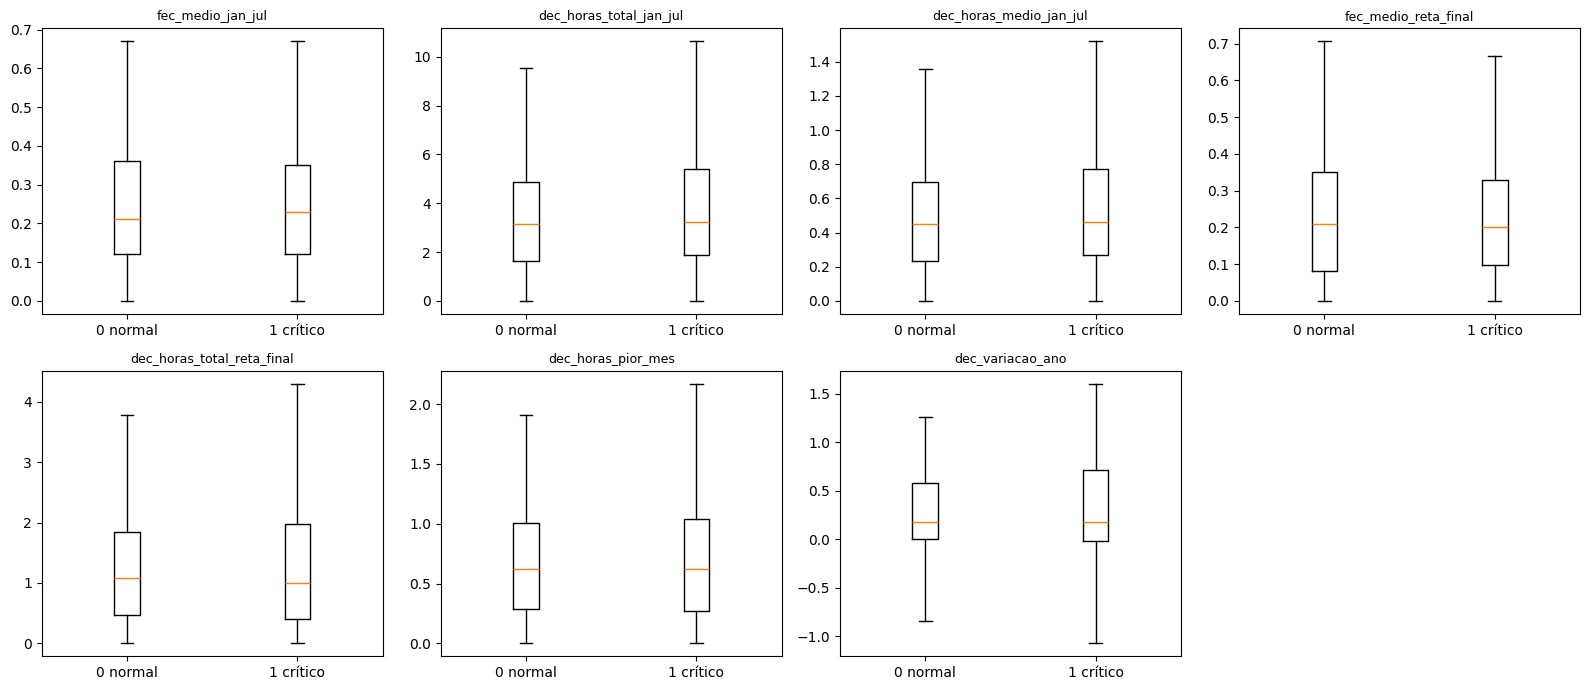

In [19]:
# Distribuição por classe: se as caixas se sobrepõem quase totalmente, a feature separa pouco
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, f in zip(axes.ravel(), FEATURES):
    g0 = df.loc[df[TARGET] == 0, f].dropna(); g1 = df.loc[df[TARGET] == 1, f].dropna()
    ax.boxplot([g0, g1], tick_labels=["0 normal", "1 crítico"], showfliers=False)
    ax.set_title(f, fontsize=9)
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

In [20]:
# Sinal univariado: AUC de cada feature sozinha (0,5 = nada; longe de 0,5 em qualquer direção = sinal)
linhas = []
for f in FEATURES:
    d = df[[f, TARGET]].dropna()
    auc = roc_auc_score(d[TARGET], d[f]) if d[TARGET].nunique() == 2 else np.nan
    rho = d[f].corr(df.loc[d.index, "taxa_abstencao"], method="spearman")
    linhas.append({"feature": f, "AUC_univariada": round(auc, 3), "spearman_vs_taxa": round(rho, 3),
                   "nulos": int(df[f].isna().sum())})
sinal = pd.DataFrame(linhas).set_index("feature")
sinal

,AUC_univariada,spearman_vs_taxa,nulos
feature,,,
fec_medio_jan_jul,0.504,0.051,0
dec_horas_total_jan_jul,0.515,0.090,0
dec_horas_medio_jan_jul,0.515,0.090,0
fec_medio_reta_final,0.503,0.047,0
dec_horas_total_reta_final,0.480,0.012,0
dec_horas_pior_mes,0.510,0.049,0
dec_variacao_ano,0.512,0.031,0


In [21]:
# Correlação por ano: o sinal tem o mesmo sentido em todos os anos? (instável = cuidado)
corr_ano = {f: {a: g[f].corr(g["taxa_abstencao"], method="spearman") for a, g in df.groupby("ano")} for f in FEATURES}
pd.DataFrame(corr_ano).T.round(2)

,2020,2021,2022,2023,2024
fec_medio_jan_jul,-0.02,0.22,-0.04,0.13,0.09
dec_horas_total_jan_jul,0.38,0.10,0.04,0.06,0.14
dec_horas_medio_jan_jul,0.38,0.10,0.04,0.06,0.14
fec_medio_reta_final,-0.08,0.07,-0.03,0.12,-0.05
dec_horas_total_reta_final,0.28,-0.01,-0.20,-0.05,0.00
dec_horas_pior_mes,0.30,0.03,-0.10,-0.02,0.06
dec_variacao_ano,0.10,-0.11,-0.26,0.03,-0.07


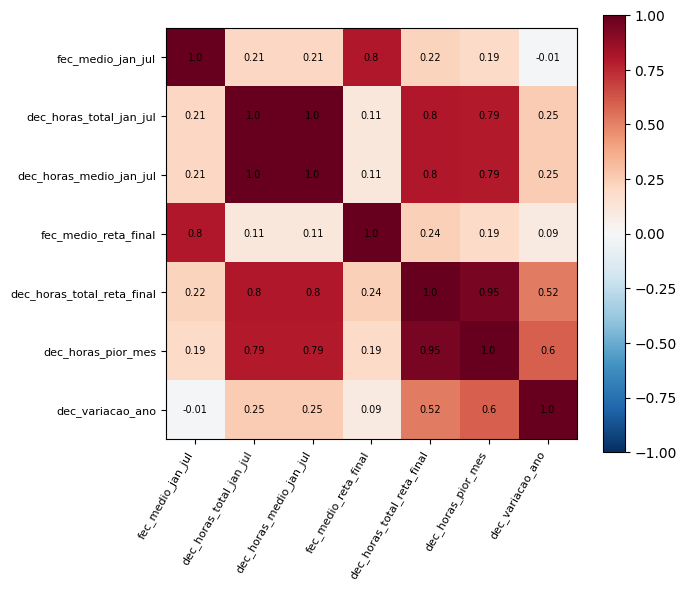

In [22]:
# Redundância entre features (várias são recortes da mesma série; |rho| > 0,9 = quase a mesma informação)
corr = df[FEATURES].corr(method="spearman").round(2)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES, fontsize=8)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center", fontsize=7)
plt.colorbar(im); plt.tight_layout(); plt.show()

## 5. Checklist anti-vazamento (com prova)
Cada item do checklist do enunciado vira uma verificação executável.

In [23]:
# 1) Toda feature existia antes do t0? Nenhuma feature pode ser coluna do futuro.
vazadas = FUTURO & set(FEATURES)
assert not vazadas, f"Feature do futuro: {vazadas}"
print("[1] OK: nenhuma feature é taxa_abstencao / total_abstencao / total_inscritos / target")

[1] OK: nenhuma feature é taxa_abstencao / total_abstencao / total_inscritos / target


In [24]:
# 2) As agregações usaram só dados anteriores ao t0? Refaz as features direto da Silver com mes <= 7
#    e compara com a Gold. Se bater, a Gold só usou jan-jul.
sj = pd.read_parquet(SILVER_JOINED)
obs = sj[sj["mes"] <= 7]
refeito = obs.groupby(CHAVE, as_index=False).agg(
    fec_ref=("fec_freq_mensal", "mean"), dec_ref=("dec_horas_mensal", "sum"))
cmp_ = gold.merge(refeito, on=CHAVE, how="left")
dif_fec = (cmp_["fec_medio_jan_jul"] - cmp_["fec_ref"]).abs().max()
dif_dec = (cmp_["dec_horas_total_jan_jul"] - cmp_["dec_ref"]).abs().max()
print(f"maior diferença FEC: {dif_fec:.4f} | DEC: {dif_dec:.4f} (tolerância 0,01 por causa do round(2))")
assert dif_fec < 0.01 and dif_dec < 0.01, "Gold não bate com jan-jul da Silver: investigar"

# Contraprova: se tivesse usado o ano inteiro, os números mudariam. Mostra que o filtro faz diferença.
ano_todo = sj.groupby(CHAVE, as_index=False).agg(dec_ano=("dec_horas_mensal", "sum"))
cp = gold.merge(ano_todo, on=CHAVE, how="left")
print("linhas em que DEC jan-jul != DEC do ano inteiro:", int(((cp["dec_horas_total_jan_jul"] - cp["dec_ano"]).abs() > 0.01).sum()), "de", len(cp))
print("[2] OK: features reproduzidas só com meses 1-7")

maior diferença FEC: 0.0043 | DEC: 0.0000 (tolerância 0,01 por causa do round(2))
linhas em que DEC jan-jul != DEC do ano inteiro: 380 de 391
[2] OK: features reproduzidas só com meses 1-7


In [25]:
# 3) O split respeita tempo e grupo?
ano_teste = int(df["ano"].max())
treino_anos = sorted(df.loc[df["ano"] < ano_teste, "ano"].unique().tolist())
assert max(treino_anos) < ano_teste, "treino não é anterior ao teste"
mun_tr = set(df.loc[df["ano"] < ano_teste, "codigo_municipio"])
mun_te = set(df.loc[df["ano"] == ano_teste, "codigo_municipio"])
print(f"[3] Tempo OK: treino {treino_anos} < teste {ano_teste}")
print(f"    Grupo: {len(mun_te & mun_tr)} de {len(mun_te)} municípios do teste também estão no treino (em anos anteriores).")
print("    É intencional: a decisão se repete todo ano sobre os mesmos municípios. Documentar na defesa.")

[3] Tempo OK: treino [2020, 2021, 2022, 2023] < teste 2024
    Grupo: 77 de 79 municípios do teste também estão no treino (em anos anteriores).
    É intencional: a decisão se repete todo ano sobre os mesmos municípios. Documentar na defesa.


In [26]:
# 4) Scaler/encoder/imputador ajustados só no treino? Não há nenhum no pipeline:
#    features numéricas, Random Forest (aceita NaN no sklearn >= 1.4). Hiperparâmetros fixos.
import sklearn
print("[4] sklearn", sklearn.__version__, "| NaN nas features:", int(df[FEATURES].isna().sum().sum()), "(o RF lida com NaN direto)")

# Alarme de métrica alta demais: AUC univariada muito alta em uma coluna = suspeita de vazamento
maior = sinal["AUC_univariada"].apply(lambda a: max(a, 1 - a)).max()
print(f"maior AUC univariada: {maior:.3f}", "-> SUSPEITO, investigar" if maior > 0.85 else "-> sem sinal de vazamento por coluna")

[4] sklearn 1.8.0 | NaN nas features: 0 (o RF lida com NaN direto)
maior AUC univariada: 0.520 -> sem sinal de vazamento por coluna


**Nota para a defesa (`total_inscritos`):** hoje ele está barrado como "futuro". As inscrições fecham antes do t0, então ele
*poderia* ser feature legítima (tamanho do município). Barrar é conservador e seguro; se o grupo quiser usar, tem que
justificar a data de fechamento das inscrições de cada ano.

**Nota para a defesa (publicação da ANEEL):** "existia antes do t0" aqui significa *ocorreu* até julho. Se a ANEEL publica o
DEC/FEC de julho com atraso, na prática o decisor não teria o dado em 31/07. Vale checar a defasagem de publicação.

## 6. Split temporal, baselines e métricas
- **Split:** treino = anos anteriores; teste = ano seguinte (validação "rolling-origin": testa cada ano usando só o passado).
  Com ~144 municípios por ano, um único ano de teste é muito ruidoso, então olhamos todos.
- **Baselines:** (a) moda (PR-AUC = prevalência); (b) persistência: abstenção do ano anterior do mesmo município.
- **Métrica principal:** PR-AUC (classe positiva minoritária). Acurácia engana. P@K liga à decisão.

In [27]:
def topk(y, score, k=K):
    # Entre os k de maior score: precisão (quantos eram críticos) e recall (quantos dos críticos reais entraram)
    k = min(k, len(y))
    idx = np.argsort(-score, kind="stable")[:k]
    return y[idx].mean(), (y[idx].sum() / y.sum() if y.sum() else np.nan)

def treinar(tr):
    # Mesmos hiperparâmetros de train_predictor.py, semente fixa
    clf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight="balanced_subsample", random_state=SEED)
    return clf.fit(tr[FEATURES], tr[TARGET])

def persistencia(tr, te):
    # Score = taxa de abstenção do ano anterior (novembro anterior ao t0, não vaza).
    # Quem não tem ano anterior recebe a mediana do TREINO (imputação ajustada só no treino).
    ant = df[CHAVE + ["taxa_abstencao"]].assign(ano=df["ano"] + 1).rename(columns={"taxa_abstencao": "taxa_ant"})
    s = te[CHAVE].merge(ant, on=CHAVE, how="left")["taxa_ant"]
    return s.fillna(tr["taxa_abstencao"].median()).to_numpy()

linhas, preds = [], {}
for a in sorted(df["ano"].unique())[1:]:
    tr, te = df[df["ano"] < a], df[df["ano"] == a]
    y = te[TARGET].to_numpy()
    if y.sum() == 0 or y.sum() == len(y) or tr[TARGET].nunique() < 2:
        linhas.append({"ano_teste": a, "obs": "uma classe só: métricas indefinidas"}); continue
    clf = treinar(tr)
    p = clf.predict_proba(te[FEATURES])[:, 1]
    sp = persistencia(tr, te)
    pk, rk = topk(y, p); pk_p, rk_p = topk(y, sp)
    preds[a] = te.assign(prob=p)
    linhas.append({
        "ano_teste": a, "n_treino": len(tr), "n_teste": len(te), "prevalencia": round(y.mean(), 3),
        "ROC_modelo": round(roc_auc_score(y, p), 3),
        "PRAUC_modelo": round(average_precision_score(y, p), 3),
        "PRAUC_persist": round(average_precision_score(y, sp), 3),
        "PRAUC_acaso(moda)": round(y.mean(), 3),
        f"P@{K}_modelo": round(pk, 3), f"P@{K}_persist": round(pk_p, 3),
        f"R@{K}_modelo": round(rk, 3), "lift@K": round(pk / y.mean(), 2),
    })
metricas = pd.DataFrame(linhas).set_index("ano_teste")
metricas

,obs,n_treino,n_teste,prevalencia,ROC_modelo,PRAUC_modelo,PRAUC_persist,PRAUC_acaso(moda),P@50_modelo,P@50_persist,R@50_modelo,lift@K
ano_teste,,,,,,,,,,,,
2021,uma classe só: métricas indefinidas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022,NaN,142.0,74.0,0.527,0.602,0.603,0.713,0.527,0.58,0.66,0.744,1.10
2023,NaN,216.0,77.0,0.377,0.528,0.414,0.731,0.377,0.36,0.50,0.621,0.96
2024,NaN,293.0,79.0,0.127,0.730,0.293,0.603,0.127,0.16,0.18,0.800,1.26


In [28]:
# Alerta: métrica alta demais é motivo de investigação, não de comemoração
if "ROC_modelo" in metricas:
    suspeitos = metricas.index[metricas["ROC_modelo"] > 0.95].tolist()
    print("anos com ROC > 0,95 (investigar vazamento):", suspeitos or "nenhum")
    venceu = (metricas["PRAUC_modelo"] > metricas["PRAUC_persist"]).sum()
    print(f"modelo de energia vence a persistência em {venceu} de {metricas['PRAUC_modelo'].notna().sum()} anos (PR-AUC)")

anos com ROC > 0,95 (investigar vazamento): nenhum
modelo de energia vence a persistência em 0 de 3 anos (PR-AUC)


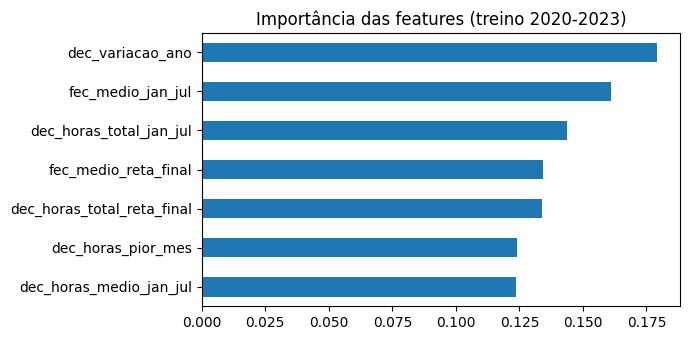

In [29]:
# Importância das features no último ano (treino = todos os anos anteriores)
tr_f, te_f = df[df["ano"] < ano_teste], df[df["ano"] == ano_teste]
clf_f = treinar(tr_f)
pd.Series(clf_f.feature_importances_, index=FEATURES).sort_values().plot(kind="barh", figsize=(7, 3.5),
    title=f"Importância das features (treino {treino_anos[0]}-{treino_anos[-1]})")
plt.tight_layout(); plt.show()

## 7. Decisão: top-K, custo de errar e sensibilidade ao K
**Decisor:** SEDUC-PA e MEC. **Ação:** gerador móvel + plano de estudo offline em K municípios entre agosto e outubro.
**Limiar:** top-K definido pela capacidade (50 geradores), não por probabilidade arbitrária.

In [30]:
# Ranking de risco do último ano, treinado só com o passado
rank = te_f.assign(prob=clf_f.predict_proba(te_f[FEATURES])[:, 1]).sort_values("prob", ascending=False)
top = rank.head(K)
tp = int(top[TARGET].sum()); fp = K - tp
fn = int(rank.iloc[K:][TARGET].sum())

print(f"Ano {ano_teste}: {len(rank)} municípios na coorte, {int(rank[TARGET].sum())} críticos de fato")
print(f"Top-{K}: {tp} acertos (TP), {fp} gerador sem necessidade (FP) | críticos deixados de fora (FN): {fn}")
print(f"Orçamento: R$ {K * CUSTO_GERADOR:,.0f} | custo do FP (gerador mal alocado): R$ {fp * CUSTO_GERADOR:,.0f}")
print(f"Inscritos nos {K} priorizados: {int(top['total_inscritos'].sum()):,} | inscritos nos {fn} críticos sem gerador (FN): "
      f"{int(rank.iloc[K:].loc[rank.iloc[K:][TARGET] == 1, 'total_inscritos'].sum()):,}")
top[["NomMunicipio", "prob", "taxa_abstencao", TARGET, "total_inscritos"]].head(15).round(3)

Ano 2024: 79 municípios na coorte, 10 críticos de fato
Top-50: 8 acertos (TP), 42 gerador sem necessidade (FP) | críticos deixados de fora (FN): 2
Orçamento: R$ 750,000 | custo do FP (gerador mal alocado): R$ 630,000
Inscritos nos 50 priorizados: 105,423 | inscritos nos 2 críticos sem gerador (FN): 1,819


,NomMunicipio,prob,taxa_abstencao,target_abstencao_critica,total_inscritos
223,NOVO PROGRESSO,0.935,0.342,0,486
179,JURUTI,0.896,0.316,0,1629
333,SÃO FÉLIX DO XINGU,0.896,0.382,1,699
288,REDENÇÃO,0.881,0.300,0,2236
39,AUGUSTO CORRÊA,0.816,0.323,0,945
303,SALINÓPOLIS,0.698,0.327,0,1965
283,PRAINHA,0.695,0.374,1,573
238,OEIRAS DO PARÁ,0.693,0.302,0,912
129,CURUÇÁ,0.688,0.310,0,1671
383,VIGIA,0.688,0.295,0,2238


In [31]:
# Sensibilidade ao K: K=50 de ~144 municípios é mais de 1/3 do estado. Quanto o lift melhora se K for menor?
y = rank[TARGET].to_numpy(); s = rank["prob"].to_numpy()
linhas = []
for k in [10, 20, 30, 50, 70, 100]:
    p_, r_ = topk(y, s, k)
    linhas.append({"K": k, "precisao": round(p_, 3), "recall": round(r_, 3),
                   "lift_vs_acaso": round(p_ / y.mean(), 2),
                   "custo_orcamento_R$": k * CUSTO_GERADOR,
                   "custo_FP_R$": round((1 - p_) * k * CUSTO_GERADOR)})
pd.DataFrame(linhas).set_index("K")

,precisao,recall,lift_vs_acaso,custo_orcamento_R$,custo_FP_R$
K,,,,,
10,0.200,0.2,1.58,150000,120000
20,0.350,0.7,2.76,300000,195000
30,0.233,0.7,1.84,450000,345000
50,0.160,0.8,1.26,750000,630000
70,0.143,1.0,1.13,1050000,900000
100,0.127,1.0,1.00,1500000,1310127


In [32]:
# Custo do falso negativo: o grupo ainda não quantificou em R$. Aqui mostramos o que os dados sustentam
# (candidatos inscritos em críticos sem gerador). Valor em R$ por candidato é decisão do grupo.
fn_df = rank.iloc[K:]
fn_df = fn_df[fn_df[TARGET] == 1]
print(f"FN: {len(fn_df)} municípios, {int(fn_df['total_inscritos'].sum()):,} inscritos, "
      f"abstenção média {fn_df['taxa_abstencao'].mean():.1%}")
fn_df[["NomMunicipio", "prob", "taxa_abstencao", "total_inscritos"]].head(10).round(3)

FN: 2 municípios, 1,819 inscritos, abstenção média 36.7%


,NomMunicipio,prob,taxa_abstencao,total_inscritos
74,BREU BRANCO,0.507,0.371,870
124,CURRALINHO,0.466,0.364,949


## 8. Resumo para o README / defesa
A célula abaixo consolida os números desta execução num JSON (vai para `data/gold/analytics/`, que está no `.gitignore`).
Copie os valores para o relatório; não escreva números de cabeça.

In [33]:
resumo = {
    "linhas_gold": int(len(gold)), "municipios": int(gold["codigo_municipio"].nunique()), "anos": anos,
    "pk_sem_duplicata": True,
    "coorte_linhas": int(len(df)), "excluidos_janela_incompleta": int(len(gold) - len(df)),
    "positivos_por_ano": df.groupby("ano")[TARGET].mean().round(3).to_dict(),
    "ano_teste": ano_teste, "K": K,
    "tp_topk": tp, "fp_topk": fp, "fn_fora_topk": fn,
    "custo_fp_R$": fp * CUSTO_GERADOR, "orcamento_R$": K * CUSTO_GERADOR,
}
GOLD_AN.mkdir(parents=True, exist_ok=True)
(GOLD_AN / "gold_exploracao_resumo.json").write_text(json.dumps(resumo, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
print(json.dumps(resumo, indent=2, ensure_ascii=False, default=str))

{
  "linhas_gold": 391,
  "municipios": 81,
  "anos": [
    2020,
    2021,
    2022,
    2023,
    2024
  ],
  "pk_sem_duplicata": true,
  "coorte_linhas": 372,
  "excluidos_janela_incompleta": 19,
  "positivos_por_ano": {
    "2020": 1.0,
    "2021": 0.732,
    "2022": 0.527,
    "2023": 0.377,
    "2024": 0.127
  },
  "ano_teste": 2024,
  "K": 50,
  "tp_topk": 8,
  "fp_topk": 42,
  "fn_fora_topk": 2,
  "custo_fp_R$": 630000,
  "orcamento_R$": 750000
}


### Limitações (confirmar com os números acima antes de entregar)
- Associação, não causalidade: renda, distância, transporte e clima não estão nos dados.
- DEC/FEC são médias de conjuntos elétricos; não captam falta de energia no local de prova.
- ~144 municípios por ano: o teste de um ano é ruidoso (por isso a validação rolling-origin).
- Limiar de 35% fixo: em 2020/2021 (pandemia; ENEM 2020 aplicado em jan/fev de 2021) a taxa de positivos muda muito. Ver seção 3.
- Se a persistência vencer o modelo de energia, dizer isso no relatório: a energia não agrega além do histórico.